⏳ Downloading images...
✅ Dataset loaded: 300 images
Epoch 1/60 | Loss: 0.138102
Epoch 2/60 | Loss: 0.129095
Epoch 3/60 | Loss: 0.125672
Epoch 4/60 | Loss: 0.122463
Epoch 5/60 | Loss: 0.122353
Epoch 6/60 | Loss: 0.119151
Epoch 7/60 | Loss: 0.119861
Epoch 8/60 | Loss: 0.119101
Epoch 9/60 | Loss: 0.116292
Epoch 10/60 | Loss: 0.115974
Epoch 11/60 | Loss: 0.114569
Epoch 12/60 | Loss: 0.113754
Epoch 13/60 | Loss: 0.114481
Epoch 14/60 | Loss: 0.113223
Epoch 15/60 | Loss: 0.112638
Epoch 16/60 | Loss: 0.112976
Epoch 17/60 | Loss: 0.111350
Epoch 18/60 | Loss: 0.111275
Epoch 19/60 | Loss: 0.111157
Epoch 20/60 | Loss: 0.111134
Epoch 21/60 | Loss: 0.110051
Epoch 22/60 | Loss: 0.110691
Epoch 23/60 | Loss: 0.109340
Epoch 24/60 | Loss: 0.110164
Epoch 25/60 | Loss: 0.108530
Epoch 26/60 | Loss: 0.108374
Epoch 27/60 | Loss: 0.109293
Epoch 28/60 | Loss: 0.109030
Epoch 29/60 | Loss: 0.107174
Epoch 30/60 | Loss: 0.107624
Epoch 31/60 | Loss: 0.106452
Epoch 32/60 | Loss: 0.107270
Epoch 33/60 | Loss: 0.107909

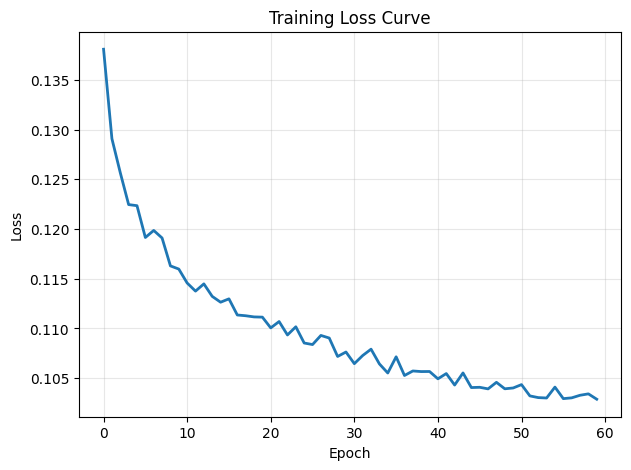


📊 PSNR: 38.30 dB


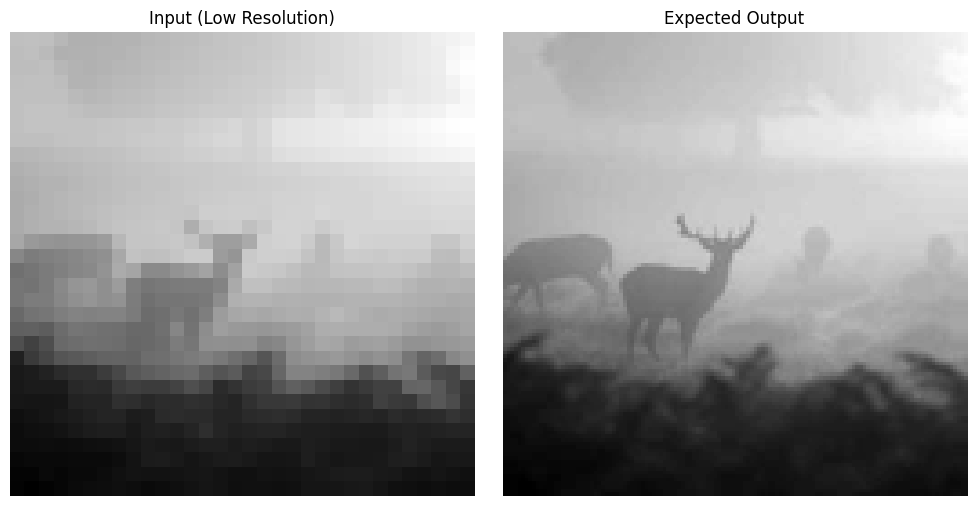

In [22]:
import os
import requests
import io
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from PIL import Image, ImageFilter
import numpy as np
import matplotlib.pyplot as plt
import torchvision.models as models
import time
import random

# Device
DEVICE = torch.device("cpu")
print("Using device:", DEVICE)

# Dataset
image_urls = [f"https://picsum.photos/seed/{i*13}/256/256" for i in range(1, 301)]

HR_raw, LR_raw = [], []

for url in image_urls:
    try:
        r = requests.get(url, timeout=10)
        if r.status_code == 200:
            img = Image.open(io.BytesIO(r.content)).convert('L')
            hr = img.resize((128, 128), Image.BICUBIC)
            lr = img.resize((32, 32), Image.BICUBIC)

            HR_raw.append(np.array(hr, dtype=np.uint8))
            LR_raw.append(np.array(lr, dtype=np.uint8))
    except:
        pass

X_train = torch.tensor(np.array(LR_raw), dtype=torch.float32).unsqueeze(1) / 255.0
y_train = torch.tensor(np.array(HR_raw), dtype=torch.float32).unsqueeze(1) / 255.0

dataset = TensorDataset(X_train, y_train)
loader = DataLoader(dataset, batch_size=8, shuffle=True)

print(f"Dataset size: {len(HR_raw)}")

# Model
class FinalSRCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.upsample = nn.Upsample(scale_factor=4, mode='bicubic', align_corners=False)
        self.conv1 = nn.Conv2d(1, 64, 9, padding=4)
        self.conv2 = nn.Conv2d(64, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 32, 3, padding=1)
        self.conv4 = nn.Conv2d(32, 1, 5, padding=2)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.upsample(x)
        residual = x
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.relu(self.conv3(x))
        x = self.conv4(x)
        return x + residual

model = FinalSRCNN().to(DEVICE)

# Loss
class PerceptualLoss(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
        self.features = nn.Sequential(*list(vgg.features)[:8]).to(DEVICE)
        for p in self.features.parameters():
            p.requires_grad = False
        self.mse = nn.MSELoss()

    def forward(self, pred, target):
        p3 = pred.repeat(1,3,1,1)
        t3 = target.repeat(1,3,1,1)
        return self.mse(pred, target) + 0.05 * self.mse(
            self.features(p3), self.features(t3)
        )

criterion = PerceptualLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training
epochs = 60
losses = []

start = time.time()

model.train()
for epoch in range(epochs):
    total = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total += loss.item()

    avg = total / len(loader)
    losses.append(avg)
    print(f"Epoch {epoch+1}/{epochs} | Loss: {avg:.6f}")

end = time.time()
cpu_time = end - start

print(f"\nCPU Time: {cpu_time:.2f} sec")

# Graph
plt.figure(figsize=(7,5))
plt.plot(losses, linewidth=2)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.savefig("loss_cpu.png", dpi=200)
plt.show()

# PSNR
def psnr(p, t):
    mse = np.mean((p - t)**2)
    return 20 * np.log10(1.0 / np.sqrt(mse + 1e-8))

# Test
model.eval()
idx = random.randint(0, len(X_train)-1)

with torch.no_grad():
    inp = X_train[idx:idx+1].to(DEVICE)
    pred = model(inp)

pred_np = pred[0].cpu().numpy().squeeze()
pred_np = np.clip(pred_np, 0, 1)

img = Image.fromarray((pred_np * 255).astype(np.uint8))
img = img.filter(ImageFilter.SMOOTH)
pred_np = np.array(img) / 255.0

target_np = y_train[idx].numpy().squeeze()
score = psnr(pred_np, target_np)

print(f"PSNR: {score:.2f} dB")

# Display
fig, ax = plt.subplots(1,2, figsize=(10,5))

ax[0].imshow(LR_raw[idx], cmap='gray')
ax[0].set_title("Input")

ax[1].imshow(pred_np, cmap='gray')
ax[1].set_title(f"Output ({score:.2f} dB)")

for a in ax:
    a.axis('off')

plt.tight_layout()
plt.savefig("result_cpu.png", dpi=200)
plt.show()

In [15]:
%%bash
apt-get install -y libcurl4-openssl-dev -q
wget -q https://raw.githubusercontent.com/nothings/stb/master/stb_image.h
echo "Done"

Reading package lists...
Building dependency tree...
Reading state information...
libcurl4-openssl-dev is already the newest version (7.81.0-1ubuntu1.23).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.
Done


In [16]:
%%writefile srcnn_gpu.cu
/*
 * SRCNN GPU - CUDA Implementation
 * HOW TO RUN ON GOOGLE COLAB:
 * ============================
 * !apt-get install -y libcurl4-openssl-dev
 * !wget -q https://raw.githubusercontent.com/nothings/stb/master/stb_image.h
 * !nvcc -O2 -o srcnn_gpu srcnn_gpu.cu -lcurl -lm -arch=sm_75 && ./srcnn_gpu
 */

#include <stdio.h>
#include <stdlib.h>
#include <string.h>
#include <math.h>
#include <time.h>
#include <cuda_runtime.h>
#include <curl/curl.h>

#define STB_IMAGE_IMPLEMENTATION
#define STBI_ONLY_JPEG
#define STBI_NO_STDIO
#include "stb_image.h"

/* ─── Configuration ──────────────────────────────────────────────── */
#define NUM_IMAGES  300
#define HR_SIZE     128
#define LR_SIZE     32
#define BATCH_SIZE  8
#define EPOCHS      60
#define LR_RATE     0.001f
#define ADAM_B1     0.9f
#define ADAM_B2     0.999f
#define ADAM_EPS    1e-8f

#define C1_IN  1
#define C1_OUT 64
#define C1_K   9
#define C2_IN  64
#define C2_OUT 64
#define C2_K   3
#define C3_IN  64
#define C3_OUT 32
#define C3_K   3
#define C4_IN  32
#define C4_OUT 1
#define C4_K   5

#define CHECK_CUDA(call) do { \
    cudaError_t e = (call); \
    if(e != cudaSuccess){ \
        fprintf(stderr,"CUDA error %s:%d: %s\n",__FILE__,__LINE__,cudaGetErrorString(e)); \
        exit(1); \
    } \
} while(0)

/* ─── HTTP Download ──────────────────────────────────────────────── */
typedef struct { unsigned char *data; size_t size; } MemBuf;

static size_t curl_cb(void *ptr, size_t size, size_t nmemb, void *userdata){
    MemBuf *buf = (MemBuf*)userdata;
    size_t bytes = size * nmemb;
    buf->data = (unsigned char*)realloc(buf->data, buf->size + bytes + 1);
    memcpy(buf->data + buf->size, ptr, bytes);
    buf->size += bytes;
    return bytes;
}

/* ─── Dataset ────────────────────────────────────────────────────── */
static float *h_LR = NULL;
static float *h_HR = NULL;
static int    g_N  = 0;

static void resize_bilinear(const float *src, int sw, int sh,
                             float *dst, int dw, int dh){
    float sx = (float)sw/dw, sy = (float)sh/dh;
    for(int dy=0;dy<dh;dy++){
        for(int dx=0;dx<dw;dx++){
            float fx=(dx+0.5f)*sx-0.5f, fy=(dy+0.5f)*sy-0.5f;
            int x0=(int)fx; if(x0<0)x0=0;
            int y0=(int)fy; if(y0<0)y0=0;
            int x1=x0+1; if(x1>=sw)x1=sw-1;
            int y1=y0+1; if(y1>=sh)y1=sh-1;
            float wx=fx-x0, wy=fy-y0;
            dst[dy*dw+dx]=
                src[y0*sw+x0]*(1-wx)*(1-wy)+
                src[y0*sw+x1]*(  wx)*(1-wy)+
                src[y1*sw+x0]*(1-wx)*(  wy)+
                src[y1*sw+x1]*(  wx)*(  wy);
        }
    }
}

static void download_dataset(void){
    CURL *curl = curl_easy_init();
    if(!curl){ fprintf(stderr,"curl init failed\n"); exit(1); }

    h_LR = (float*)malloc(NUM_IMAGES * LR_SIZE * LR_SIZE * sizeof(float));
    h_HR = (float*)malloc(NUM_IMAGES * HR_SIZE * HR_SIZE * sizeof(float));
    float *tmp = (float*)malloc(256*256*sizeof(float));

    for(int i=1; i<=NUM_IMAGES; i++){
        char url[128];
        sprintf(url,"https://picsum.photos/seed/%d/256/256", i*13);
        MemBuf buf = {NULL, 0};
        curl_easy_setopt(curl, CURLOPT_URL, url);
        curl_easy_setopt(curl, CURLOPT_WRITEFUNCTION, curl_cb);
        curl_easy_setopt(curl, CURLOPT_WRITEDATA, &buf);
        curl_easy_setopt(curl, CURLOPT_TIMEOUT, 15L);
        curl_easy_setopt(curl, CURLOPT_FOLLOWLOCATION, 1L);
        CURLcode rc = curl_easy_perform(curl);
        if(rc != CURLE_OK){ free(buf.data); continue; }

        int w,h,c;
        unsigned char *img = stbi_load_from_memory(buf.data,(int)buf.size,&w,&h,&c,1);
        free(buf.data);
        if(!img) continue;

        for(int p=0;p<w*h;p++) tmp[p]=img[p]/255.0f;
        stbi_image_free(img);

        int idx = g_N;
        resize_bilinear(tmp,w,h, h_HR+idx*HR_SIZE*HR_SIZE, HR_SIZE, HR_SIZE);
        resize_bilinear(tmp,w,h, h_LR+idx*LR_SIZE*LR_SIZE, LR_SIZE, LR_SIZE);
        g_N++;
        if(g_N%50==0) printf("Downloaded %d images...\n", g_N);
    }
    free(tmp);
    curl_easy_cleanup(curl);
    printf("Dataset ready: %d images\n", g_N);
}

/* ─── GPU helpers ────────────────────────────────────────────────── */
static float* gpu_alloc(size_t n){
    float *p; CHECK_CUDA(cudaMalloc(&p, n*sizeof(float))); return p;
}
static void gpu_zero(float *p, size_t n){
    CHECK_CUDA(cudaMemset(p,0,n*sizeof(float)));
}
static int blk256(int n){ return (n+255)/256; }

/* ─── CUDA Kernels ───────────────────────────────────────────────── */

__global__ void k_upsample4(const float* __restrict__ src,
                              float* __restrict__ dst,
                              int N, int C, int IH, int IW){
    int OH=IH*4, OW=IW*4;
    int idx=blockIdx.x*blockDim.x+threadIdx.x;
    if(idx>=N*C*OH*OW) return;
    int ow=idx%OW; int t=idx/OW;
    int oh=t%OH;   t/=OH;
    int c=t%C;     t/=C;
    int n=t;
    float fx=(ow+0.5f)/4.0f-0.5f, fy=(oh+0.5f)/4.0f-0.5f;
    int x0=(int)fx; if(x0<0)x0=0;
    int y0=(int)fy; if(y0<0)y0=0;
    int x1=x0+1; if(x1>=IW)x1=IW-1;
    int y1=y0+1; if(y1>=IH)y1=IH-1;
    float wx=fx-x0, wy=fy-y0;
    int base=(n*C+c)*IH*IW;
    dst[idx]=src[base+y0*IW+x0]*(1-wx)*(1-wy)
            +src[base+y0*IW+x1]*(  wx)*(1-wy)
            +src[base+y1*IW+x0]*(1-wx)*(  wy)
            +src[base+y1*IW+x1]*(  wx)*(  wy);
}

__global__ void k_conv2d_fwd(
    const float* __restrict__ x,
    const float* __restrict__ w,
    const float* __restrict__ b,
    float*       __restrict__ y,
    int N, int Cin, int Cout,
    int H, int W, int K, int pad, bool relu){
    int idx=blockIdx.x*blockDim.x+threadIdx.x;
    if(idx>=N*Cout*H*W) return;
    int ow=idx%W; int t=idx/W;
    int oh=t%H;   t/=H;
    int oc=t%Cout; t/=Cout;
    int n=t;
    float acc=b[oc];
    for(int ic=0;ic<Cin;ic++)
        for(int ky=0;ky<K;ky++)
            for(int kx=0;kx<K;kx++){
                int ih=oh+ky-pad, iw=ow+kx-pad;
                if(ih<0||ih>=H||iw<0||iw>=W) continue;
                acc+=x[(n*Cin+ic)*H*W+ih*W+iw]*w[(oc*Cin+ic)*K*K+ky*K+kx];
            }
    if(relu&&acc<0) acc=0;
    y[idx]=acc;
}

__global__ void k_conv2d_bwd_w(
    const float* __restrict__ x,
    const float* __restrict__ dy,
    float*       __restrict__ dw,
    int N, int Cin, int Cout,
    int H, int W, int K, int pad){
    int idx=blockIdx.x*blockDim.x+threadIdx.x;
    if(idx>=Cout*Cin*K*K) return;
    int kx=idx%K; int t=idx/K;
    int ky=t%K;   t/=K;
    int ic=t%Cin; t/=Cin;
    int oc=t;
    float g=0;
    for(int n=0;n<N;n++)
        for(int oh=0;oh<H;oh++)
            for(int ow=0;ow<W;ow++){
                int ih=oh+ky-pad, iw=ow+kx-pad;
                if(ih<0||ih>=H||iw<0||iw>=W) continue;
                g+=x[(n*Cin+ic)*H*W+ih*W+iw]*dy[(n*Cout+oc)*H*W+oh*W+ow];
            }
    atomicAdd(&dw[idx],g);
}

__global__ void k_conv2d_bwd_b(
    const float* __restrict__ dy,
    float*       __restrict__ db,
    int N, int Cout, int H, int W){
    int oc=blockIdx.x*blockDim.x+threadIdx.x;
    if(oc>=Cout) return;
    float g=0;
    for(int n=0;n<N;n++)
        for(int oh=0;oh<H;oh++)
            for(int ow=0;ow<W;ow++)
                g+=dy[(n*Cout+oc)*H*W+oh*W+ow];
    db[oc]+=g;
}

__global__ void k_conv2d_bwd_x(
    const float* __restrict__ dy,
    const float* __restrict__ w,
    float*       __restrict__ dx,
    int N, int Cin, int Cout,
    int H, int W, int K, int pad){
    int idx=blockIdx.x*blockDim.x+threadIdx.x;
    if(idx>=N*Cin*H*W) return;
    int iw=idx%W; int t=idx/W;
    int ih=t%H;   t/=H;
    int ic=t%Cin; t/=Cin;
    int n=t;
    float g=0;
    for(int oc=0;oc<Cout;oc++)
        for(int ky=0;ky<K;ky++)
            for(int kx=0;kx<K;kx++){
                int oh=ih-ky+pad, ow=iw-kx+pad;
                if(oh<0||oh>=H||ow<0||ow>=W) continue;
                g+=dy[(n*Cout+oc)*H*W+oh*W+ow]*w[(oc*Cin+ic)*K*K+ky*K+kx];
            }
    dx[idx]+=g;
}

__global__ void k_relu_bwd(float* __restrict__ dx,
                            const float* __restrict__ pre,
                            const float* __restrict__ dy, int n){
    int i=blockIdx.x*blockDim.x+threadIdx.x;
    if(i<n) dx[i]=(pre[i]>0)?dy[i]:0.0f;
}

__global__ void k_add(float* __restrict__ a, const float* __restrict__ b, int n){
    int i=blockIdx.x*blockDim.x+threadIdx.x;
    if(i<n) a[i]+=b[i];
}

__global__ void k_mse_loss(
    const float* __restrict__ pred,
    const float* __restrict__ tgt,
    float* __restrict__ loss,
    float* __restrict__ grad, int n){
    int i=blockIdx.x*blockDim.x+threadIdx.x;
    if(i>=n) return;
    float d=pred[i]-tgt[i];
    atomicAdd(loss, d*d/n);
    grad[i]=2.0f*d/n;
}

__global__ void k_adam(
    float* __restrict__ p, float* __restrict__ g,
    float* __restrict__ m, float* __restrict__ v,
    int n, float lr, float b1, float b2, float eps,
    float bc1, float bc2){
    int i=blockIdx.x*blockDim.x+threadIdx.x;
    if(i>=n) return;
    float gi=g[i];
    m[i]=b1*m[i]+(1-b1)*gi;
    v[i]=b2*v[i]+(1-b2)*gi*gi;
    float mh=m[i]/bc1, vh=v[i]/bc2;
    p[i]-=lr*mh/(sqrtf(vh)+eps);
    g[i]=0;
}

/* ─── Layer ──────────────────────────────────────────────────────── */
struct Conv {
    int Cin,Cout,K,pad;
    float *w,*b,*dw,*db,*mw,*vw,*mb,*vb;
    size_t param_w, param_b;
};

static void conv_init(Conv &c, int Cin, int Cout, int K, int pad){
    c.Cin=Cin; c.Cout=Cout; c.K=K; c.pad=pad;
    c.param_w=(size_t)Cout*Cin*K*K; c.param_b=Cout;
    c.w =gpu_alloc(c.param_w); c.dw=gpu_alloc(c.param_w);
    c.b =gpu_alloc(c.param_b); c.db=gpu_alloc(c.param_b);
    c.mw=gpu_alloc(c.param_w); c.vw=gpu_alloc(c.param_w);
    c.mb=gpu_alloc(c.param_b); c.vb=gpu_alloc(c.param_b);
    gpu_zero(c.dw,c.param_w); gpu_zero(c.mw,c.param_w); gpu_zero(c.vw,c.param_w);
    gpu_zero(c.db,c.param_b); gpu_zero(c.mb,c.param_b); gpu_zero(c.vb,c.param_b);
    gpu_zero(c.b, c.param_b);
    float *tmp=(float*)malloc(c.param_w*sizeof(float));
    float std=sqrtf(2.0f/(Cin*K*K));
    srand(42);
    for(size_t i=0;i<c.param_w;i++){
        float u1=((float)rand()+1)/(RAND_MAX+2.0f);
        float u2=((float)rand()+1)/(RAND_MAX+2.0f);
        tmp[i]=std*sqrtf(-2*logf(u1))*cosf(2*3.14159265f*u2);
    }
    CHECK_CUDA(cudaMemcpy(c.w,tmp,c.param_w*sizeof(float),cudaMemcpyHostToDevice));
    free(tmp);
}

static void conv_adam(Conv &c, int step){
    float bc1=1-powf(ADAM_B1,step), bc2=1-powf(ADAM_B2,step);
    int tw=c.param_w, tb=c.param_b;
    k_adam<<<blk256(tw),256>>>(c.w,c.dw,c.mw,c.vw,tw,LR_RATE,ADAM_B1,ADAM_B2,ADAM_EPS,bc1,bc2);
    k_adam<<<blk256(tb),256>>>(c.b,c.db,c.mb,c.vb,tb,LR_RATE,ADAM_B1,ADAM_B2,ADAM_EPS,bc1,bc2);
}

/* ─── Feature maps ───────────────────────────────────────────────── */
struct FMaps {
    float *up,*a1,*r1,*a2,*r2,*a3,*r3,*a4,*out;
    float *g_out,*g_a4,*g_r3,*g_a3,*g_r2,*g_a2,*g_r1,*g_a1;
};
static FMaps FM;
static Conv  L[4];

static void fmaps_alloc(int B){
    int HW=HR_SIZE*HR_SIZE;
    FM.up   =gpu_alloc((size_t)B*1 *HW); FM.a1=gpu_alloc((size_t)B*64*HW);
    FM.r1   =gpu_alloc((size_t)B*64*HW); FM.a2=gpu_alloc((size_t)B*64*HW);
    FM.r2   =gpu_alloc((size_t)B*64*HW); FM.a3=gpu_alloc((size_t)B*32*HW);
    FM.r3   =gpu_alloc((size_t)B*32*HW); FM.a4=gpu_alloc((size_t)B*1 *HW);
    FM.out  =gpu_alloc((size_t)B*1 *HW);
    FM.g_out=gpu_alloc((size_t)B*1 *HW); FM.g_a4=gpu_alloc((size_t)B*1 *HW);
    FM.g_r3 =gpu_alloc((size_t)B*32*HW); FM.g_a3=gpu_alloc((size_t)B*32*HW);
    FM.g_r2 =gpu_alloc((size_t)B*64*HW); FM.g_a2=gpu_alloc((size_t)B*64*HW);
    FM.g_r1 =gpu_alloc((size_t)B*64*HW); FM.g_a1=gpu_alloc((size_t)B*64*HW);
}

static void model_forward(float *d_x, int B){
    int HW=HR_SIZE*HR_SIZE;
    int n1=B*C1_OUT*HW, n2=B*C2_OUT*HW, n3=B*C3_OUT*HW, n4=B*C4_OUT*HW;
    int up_n=B*1*HW;

    k_upsample4<<<blk256(up_n),256>>>(d_x,FM.up,B,1,LR_SIZE,LR_SIZE);

    /* pre-relu (for bwd) + relu output */
    k_conv2d_fwd<<<blk256(n1),256>>>(FM.up,L[0].w,L[0].b,FM.a1,B,C1_IN,C1_OUT,HR_SIZE,HR_SIZE,C1_K,4,false);
    k_conv2d_fwd<<<blk256(n1),256>>>(FM.up,L[0].w,L[0].b,FM.r1,B,C1_IN,C1_OUT,HR_SIZE,HR_SIZE,C1_K,4,true);

    k_conv2d_fwd<<<blk256(n2),256>>>(FM.r1,L[1].w,L[1].b,FM.a2,B,C2_IN,C2_OUT,HR_SIZE,HR_SIZE,C2_K,1,false);
    k_conv2d_fwd<<<blk256(n2),256>>>(FM.r1,L[1].w,L[1].b,FM.r2,B,C2_IN,C2_OUT,HR_SIZE,HR_SIZE,C2_K,1,true);

    k_conv2d_fwd<<<blk256(n3),256>>>(FM.r2,L[2].w,L[2].b,FM.a3,B,C3_IN,C3_OUT,HR_SIZE,HR_SIZE,C3_K,1,false);
    k_conv2d_fwd<<<blk256(n3),256>>>(FM.r2,L[2].w,L[2].b,FM.r3,B,C3_IN,C3_OUT,HR_SIZE,HR_SIZE,C3_K,1,true);

    k_conv2d_fwd<<<blk256(n4),256>>>(FM.r3,L[3].w,L[3].b,FM.a4,B,C4_IN,C4_OUT,HR_SIZE,HR_SIZE,C4_K,2,false);

    CHECK_CUDA(cudaMemcpy(FM.out,FM.a4,n4*sizeof(float),cudaMemcpyDeviceToDevice));
    k_add<<<blk256(n4),256>>>(FM.out,FM.up,n4);
}

static void model_backward(float *d_hr, int B, float *d_loss){
    int HW=HR_SIZE*HR_SIZE;
    int n1=B*C1_OUT*HW, n2=B*C2_OUT*HW, n3=B*C3_OUT*HW, n4=B*1*HW;

    gpu_zero(d_loss,1); gpu_zero(FM.g_out,n4);
    k_mse_loss<<<blk256(n4),256>>>(FM.out,d_hr,d_loss,FM.g_out,n4);

    CHECK_CUDA(cudaMemcpy(FM.g_a4,FM.g_out,n4*sizeof(float),cudaMemcpyDeviceToDevice));

    gpu_zero(L[3].dw,L[3].param_w); gpu_zero(L[3].db,L[3].param_b); gpu_zero(FM.g_r3,n3);
    k_conv2d_bwd_w<<<blk256(L[3].param_w),256>>>(FM.r3,FM.g_a4,L[3].dw,B,C4_IN,C4_OUT,HR_SIZE,HR_SIZE,C4_K,2);
    k_conv2d_bwd_b<<<blk256(C4_OUT),256>>>(FM.g_a4,L[3].db,B,C4_OUT,HR_SIZE,HR_SIZE);
    k_conv2d_bwd_x<<<blk256(n3),256>>>(FM.g_a4,L[3].w,FM.g_r3,B,C4_IN,C4_OUT,HR_SIZE,HR_SIZE,C4_K,2);

    gpu_zero(FM.g_a3,n3);
    k_relu_bwd<<<blk256(n3),256>>>(FM.g_a3,FM.a3,FM.g_r3,n3);

    gpu_zero(L[2].dw,L[2].param_w); gpu_zero(L[2].db,L[2].param_b); gpu_zero(FM.g_r2,n2);
    k_conv2d_bwd_w<<<blk256(L[2].param_w),256>>>(FM.r2,FM.g_a3,L[2].dw,B,C3_IN,C3_OUT,HR_SIZE,HR_SIZE,C3_K,1);
    k_conv2d_bwd_b<<<blk256(C3_OUT),256>>>(FM.g_a3,L[2].db,B,C3_OUT,HR_SIZE,HR_SIZE);
    k_conv2d_bwd_x<<<blk256(n2),256>>>(FM.g_a3,L[2].w,FM.g_r2,B,C3_IN,C3_OUT,HR_SIZE,HR_SIZE,C3_K,1);

    gpu_zero(FM.g_a2,n2);
    k_relu_bwd<<<blk256(n2),256>>>(FM.g_a2,FM.a2,FM.g_r2,n2);

    gpu_zero(L[1].dw,L[1].param_w); gpu_zero(L[1].db,L[1].param_b); gpu_zero(FM.g_r1,n1);
    k_conv2d_bwd_w<<<blk256(L[1].param_w),256>>>(FM.r1,FM.g_a2,L[1].dw,B,C2_IN,C2_OUT,HR_SIZE,HR_SIZE,C2_K,1);
    k_conv2d_bwd_b<<<blk256(C2_OUT),256>>>(FM.g_a2,L[1].db,B,C2_OUT,HR_SIZE,HR_SIZE);
    k_conv2d_bwd_x<<<blk256(n1),256>>>(FM.g_a2,L[1].w,FM.g_r1,B,C2_IN,C2_OUT,HR_SIZE,HR_SIZE,C2_K,1);

    gpu_zero(FM.g_a1,n1);
    k_relu_bwd<<<blk256(n1),256>>>(FM.g_a1,FM.a1,FM.g_r1,n1);

    gpu_zero(L[0].dw,L[0].param_w); gpu_zero(L[0].db,L[0].param_b);
    k_conv2d_bwd_w<<<blk256(L[0].param_w),256>>>(FM.up,FM.g_a1,L[0].dw,B,C1_IN,C1_OUT,HR_SIZE,HR_SIZE,C1_K,4);
    k_conv2d_bwd_b<<<blk256(C1_OUT),256>>>(FM.g_a1,L[0].db,B,C1_OUT,HR_SIZE,HR_SIZE);
}

/* ─── Save PGM ───────────────────────────────────────────────────── */
static void save_pgm(const char *path, const float *data, int W, int H){
    FILE *f=fopen(path,"wb");
    fprintf(f,"P5\n%d %d\n255\n",W,H);
    unsigned char *row=(unsigned char*)malloc(W);
    for(int y=0;y<H;y++){
        for(int x=0;x<W;x++){
            float v=data[y*W+x];
            if(v<0)v=0; if(v>1)v=1;
            row[x]=(unsigned char)(v*255);
        }
        fwrite(row,1,W,f);
    }
    free(row); fclose(f);
}

/* ─── Main ───────────────────────────────────────────────────────── */
int main(void){
    printf("=== SRCNN GPU (CUDA) ===\n");

    int devCount;
    CHECK_CUDA(cudaGetDeviceCount(&devCount));
    if(devCount==0){ fprintf(stderr,"No CUDA devices!\n"); return 1; }
    cudaDeviceProp prop;
    CHECK_CUDA(cudaGetDeviceProperties(&prop,0));
    printf("GPU: %s\n", prop.name);

    download_dataset();
    int N = g_N;

    float *d_LR, *d_HR;
    CHECK_CUDA(cudaMalloc(&d_LR,(size_t)N*LR_SIZE*LR_SIZE*sizeof(float)));
    CHECK_CUDA(cudaMalloc(&d_HR,(size_t)N*HR_SIZE*HR_SIZE*sizeof(float)));
    CHECK_CUDA(cudaMemcpy(d_LR,h_LR,(size_t)N*LR_SIZE*LR_SIZE*sizeof(float),cudaMemcpyHostToDevice));
    CHECK_CUDA(cudaMemcpy(d_HR,h_HR,(size_t)N*HR_SIZE*HR_SIZE*sizeof(float),cudaMemcpyHostToDevice));

    conv_init(L[0],C1_IN,C1_OUT,C1_K,4);
    conv_init(L[1],C2_IN,C2_OUT,C2_K,1);
    conv_init(L[2],C3_IN,C3_OUT,C3_K,1);
    conv_init(L[3],C4_IN,C4_OUT,C4_K,2);
    fmaps_alloc(BATCH_SIZE);

    float *d_blr=gpu_alloc((size_t)BATCH_SIZE*LR_SIZE*LR_SIZE);
    float *d_bhr=gpu_alloc((size_t)BATCH_SIZE*HR_SIZE*HR_SIZE);
    float *d_loss=gpu_alloc(1);
    float h_loss;

    int *idx=(int*)malloc(N*sizeof(int));
    for(int i=0;i<N;i++) idx[i]=i;

    FILE *flog=fopen("loss_gpu.csv","w");
    fprintf(flog,"epoch,loss\n");

    int step=0, batches=N/BATCH_SIZE;
    clock_t t0=clock();

    for(int ep=0;ep<EPOCHS;ep++){
        for(int i=N-1;i>0;i--){
            int j=rand()%(i+1); int t=idx[i]; idx[i]=idx[j]; idx[j]=t;
        }
        float ep_loss=0;
        for(int bi=0;bi<batches;bi++){
            step++;
            for(int k=0;k<BATCH_SIZE;k++){
                int ii=idx[bi*BATCH_SIZE+k];
                CHECK_CUDA(cudaMemcpy(d_blr+k*LR_SIZE*LR_SIZE,
                    d_LR+(size_t)ii*LR_SIZE*LR_SIZE,
                    LR_SIZE*LR_SIZE*sizeof(float),cudaMemcpyDeviceToDevice));
                CHECK_CUDA(cudaMemcpy(d_bhr+k*HR_SIZE*HR_SIZE,
                    d_HR+(size_t)ii*HR_SIZE*HR_SIZE,
                    HR_SIZE*HR_SIZE*sizeof(float),cudaMemcpyDeviceToDevice));
            }
            model_forward(d_blr, BATCH_SIZE);
            model_backward(d_bhr, BATCH_SIZE, d_loss);
            for(int li=0;li<4;li++) conv_adam(L[li],step);
            CHECK_CUDA(cudaMemcpy(&h_loss,d_loss,sizeof(float),cudaMemcpyDeviceToHost));
            ep_loss+=h_loss;
        }
        float avg=ep_loss/batches;
        printf("Epoch %2d/%d | Loss: %.6f\n", ep+1, EPOCHS, avg);
        fprintf(flog,"%d,%.6f\n", ep+1, avg);
    }

    printf("\nGPU Time: %.2f sec\n",(double)(clock()-t0)/CLOCKS_PER_SEC);
    fclose(flog);

    /* Inference */
    model_forward(d_LR, 1);

    float *h_out=(float*)malloc(HR_SIZE*HR_SIZE*sizeof(float));
    float *h_hr =(float*)malloc(HR_SIZE*HR_SIZE*sizeof(float));
    float *h_lr =(float*)malloc(LR_SIZE*LR_SIZE*sizeof(float));
    CHECK_CUDA(cudaMemcpy(h_out,FM.out,HR_SIZE*HR_SIZE*sizeof(float),cudaMemcpyDeviceToHost));
    CHECK_CUDA(cudaMemcpy(h_hr,d_HR,HR_SIZE*HR_SIZE*sizeof(float),cudaMemcpyDeviceToHost));
    CHECK_CUDA(cudaMemcpy(h_lr,d_LR,LR_SIZE*LR_SIZE*sizeof(float),cudaMemcpyDeviceToHost));

    for(int i=0;i<HR_SIZE*HR_SIZE;i++){ if(h_out[i]<0)h_out[i]=0; if(h_out[i]>1)h_out[i]=1; }

    float mse=0;
    for(int i=0;i<HR_SIZE*HR_SIZE;i++){ float d=h_out[i]-h_hr[i]; mse+=d*d; }
    mse/=HR_SIZE*HR_SIZE;
    float psnr=20*log10f(1.0f/sqrtf(mse+1e-8f));
    printf("PSNR: %.2f dB\n", psnr);

    FILE *fp=fopen("psnr.txt","w"); fprintf(fp,"PSNR: %.2f dB\n",psnr); fclose(fp);
    save_pgm("result_input.pgm",  h_lr, LR_SIZE, LR_SIZE);
    save_pgm("result_output.pgm", h_out,HR_SIZE, HR_SIZE);

    printf("\nOutputs: loss_gpu.csv | result_input.pgm | result_output.pgm | psnr.txt\n");
    free(h_out); free(h_hr); free(h_lr); free(h_LR); free(h_HR); free(idx);
    return 0;
}


Writing srcnn_gpu.cu


In [18]:
%%bash
nvcc -O2 -o srcnn_gpu srcnn_gpu.cu -lcurl -lm -arch=sm_75
./srcnn_gpu

=== SRCNN GPU (CUDA) ===
GPU: Tesla T4
Downloaded 50 images...
Downloaded 100 images...
Downloaded 150 images...
Downloaded 200 images...
Downloaded 250 images...
Downloaded 300 images...
Dataset ready: 300 images
Epoch  1/60 | Loss: 0.021517
Epoch  2/60 | Loss: 0.005880
Epoch  3/60 | Loss: 0.005688
Epoch  4/60 | Loss: 0.005705
Epoch  5/60 | Loss: 0.005673
Epoch  6/60 | Loss: 0.005699
Epoch  7/60 | Loss: 0.005654
Epoch  8/60 | Loss: 0.005652
Epoch  9/60 | Loss: 0.005549
Epoch 10/60 | Loss: 0.005598
Epoch 11/60 | Loss: 0.005632
Epoch 12/60 | Loss: 0.005575
Epoch 13/60 | Loss: 0.005598
Epoch 14/60 | Loss: 0.005558
Epoch 15/60 | Loss: 0.005561
Epoch 16/60 | Loss: 0.005575
Epoch 17/60 | Loss: 0.005562
Epoch 18/60 | Loss: 0.005570
Epoch 19/60 | Loss: 0.005581
Epoch 20/60 | Loss: 0.005589
Epoch 21/60 | Loss: 0.005535
Epoch 22/60 | Loss: 0.005503
Epoch 23/60 | Loss: 0.005537
Epoch 24/60 | Loss: 0.005555
Epoch 25/60 | Loss: 0.005532
Epoch 26/60 | Loss: 0.005536
Epoch 27/60 | Loss: 0.005416
Epo

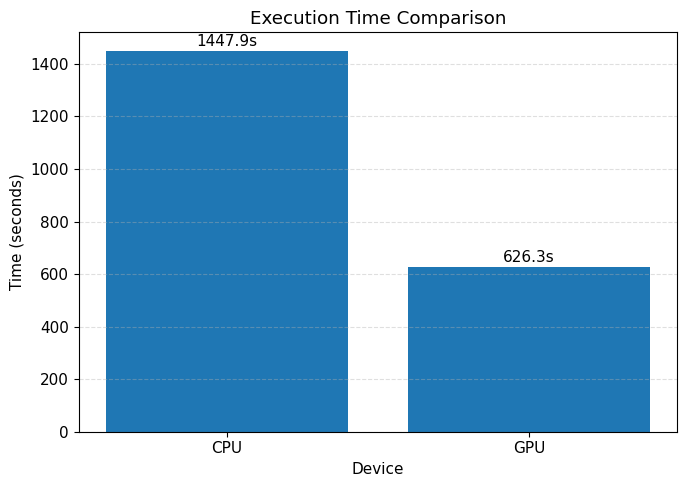

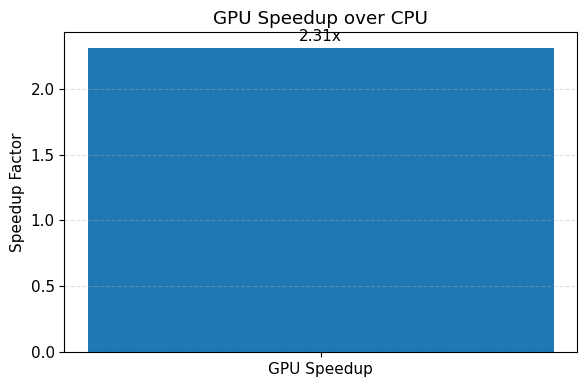

CPU: 1447.88s | GPU: 626.26s | Speedup: 2.31x


In [1]:
import matplotlib.pyplot as plt

cpu_time = 1447.88
gpu_time = 626.26
speedup = cpu_time / gpu_time

plt.rcParams.update({"font.size": 11})

# Time comparison
plt.figure(figsize=(7,5))
labels = ['CPU', 'GPU']
times = [cpu_time, gpu_time]

bars = plt.bar(labels, times)
for b in bars:
    y = b.get_height()
    plt.text(b.get_x() + b.get_width()/2, y + 20, f'{y:.1f}s', ha='center')

plt.title("Execution Time Comparison")
plt.ylabel("Time (seconds)")
plt.xlabel("Device")
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("execution_time_comparison.png", dpi=300)
plt.show()

# Speedup
plt.figure(figsize=(6,4))
plt.bar(['GPU Speedup'], [speedup])
plt.text(0, speedup + 0.05, f'{speedup:.2f}x', ha='center')

plt.title("GPU Speedup over CPU")
plt.ylabel("Speedup Factor")
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("gpu_speedup.png", dpi=300)
plt.show()

print(f"CPU: {cpu_time:.2f}s | GPU: {gpu_time:.2f}s | Speedup: {speedup:.2f}x")